# Figure 5: ARISTA

Draw Figure 5 from generated cell states, communication scores, and per-cell
velocity and growth arrays. No completed figure is used as an input.

Run this notebook from the [source checkout](../../installation.md).
The first cell downloads the spatial populations, communication scores and
lineage labels. The velocity and growth arrays are included with the code.

The [ARISTA analysis tutorial](../dataset_workflows/arista.ipynb) shows how to
load the trained model, simulate populations and evaluate growth. Here we use
the saved paper populations and velocity arrays to reproduce the displayed panels.
Panel a uses the original unwarped populations in `slice_data`. Panel b uses
the separately anchored display population in `display_states`. These are
different files and are selected explicitly below.

For model evaluation before plotting, see [Calculate Figure 5 from the trained
model](arista_model_fields.md). That page gives the model-loading, velocity
projection and growth calculations, including their output filenames.

In [1]:
import os
from pathlib import Path

import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
data = project / "data/arista/paper"
if not (data / "all_time_communications.pkl").is_file():
    cb.datasets.download("arista", destination=project,
                         kind="arista_figure_data.zip")
output = project / Path("outputs/arista_paper")
output.mkdir(parents=True, exist_ok=True)

def show(paths):
    for path in paths:
        if Path(path).suffix == ".png":
            display(Image(filename=str(path), width=850))

if not (data / "display_states/time_0.h5ad").is_file():
    cb.datasets.download("arista", destination=project,
                         kind="arista_spatial_display_data.zip")

In [2]:
import numpy as np
import pandas as pd
from reproduction.arista.main_figure import SOURCE, draw_main_figure

## a. Spatial dynamics

Use the five unwarped populations at model times 0, 0.5, 1, 1.5 and 2 (2, 3.5, 5, 7.5 and 10 DPI). Their cell counts are 7,668, 7,780, 8,106, 8,608 and 9,436.

Count transitions between labels of the same simulated particles to draw lineage connections. Communication arrows use the saved model-derived cell-type matrices. Spatial anchors are calculated from the coordinates of each cell type. The plotting code applies the original camera, colours and annotations.

[edges] 0.0: total_after_thresh=24, after_focus=24, kept=6
[edges] 0.5: total_after_thresh=15, after_focus=15, kept=6
[edges] 1.0: total_after_thresh=19, after_focus=19, kept=6
[edges] 1.5: total_after_thresh=19, after_focus=19, kept=6
[edges] 2.0: total_after_thresh=25, after_focus=25, kept=6
[edges_drawn] 0.0: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=5
[edges_drawn] 0.5: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=4
[edges_drawn] 1.0: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=3
[edges_drawn] 1.5: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=5
[edges_drawn] 2.0: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=4


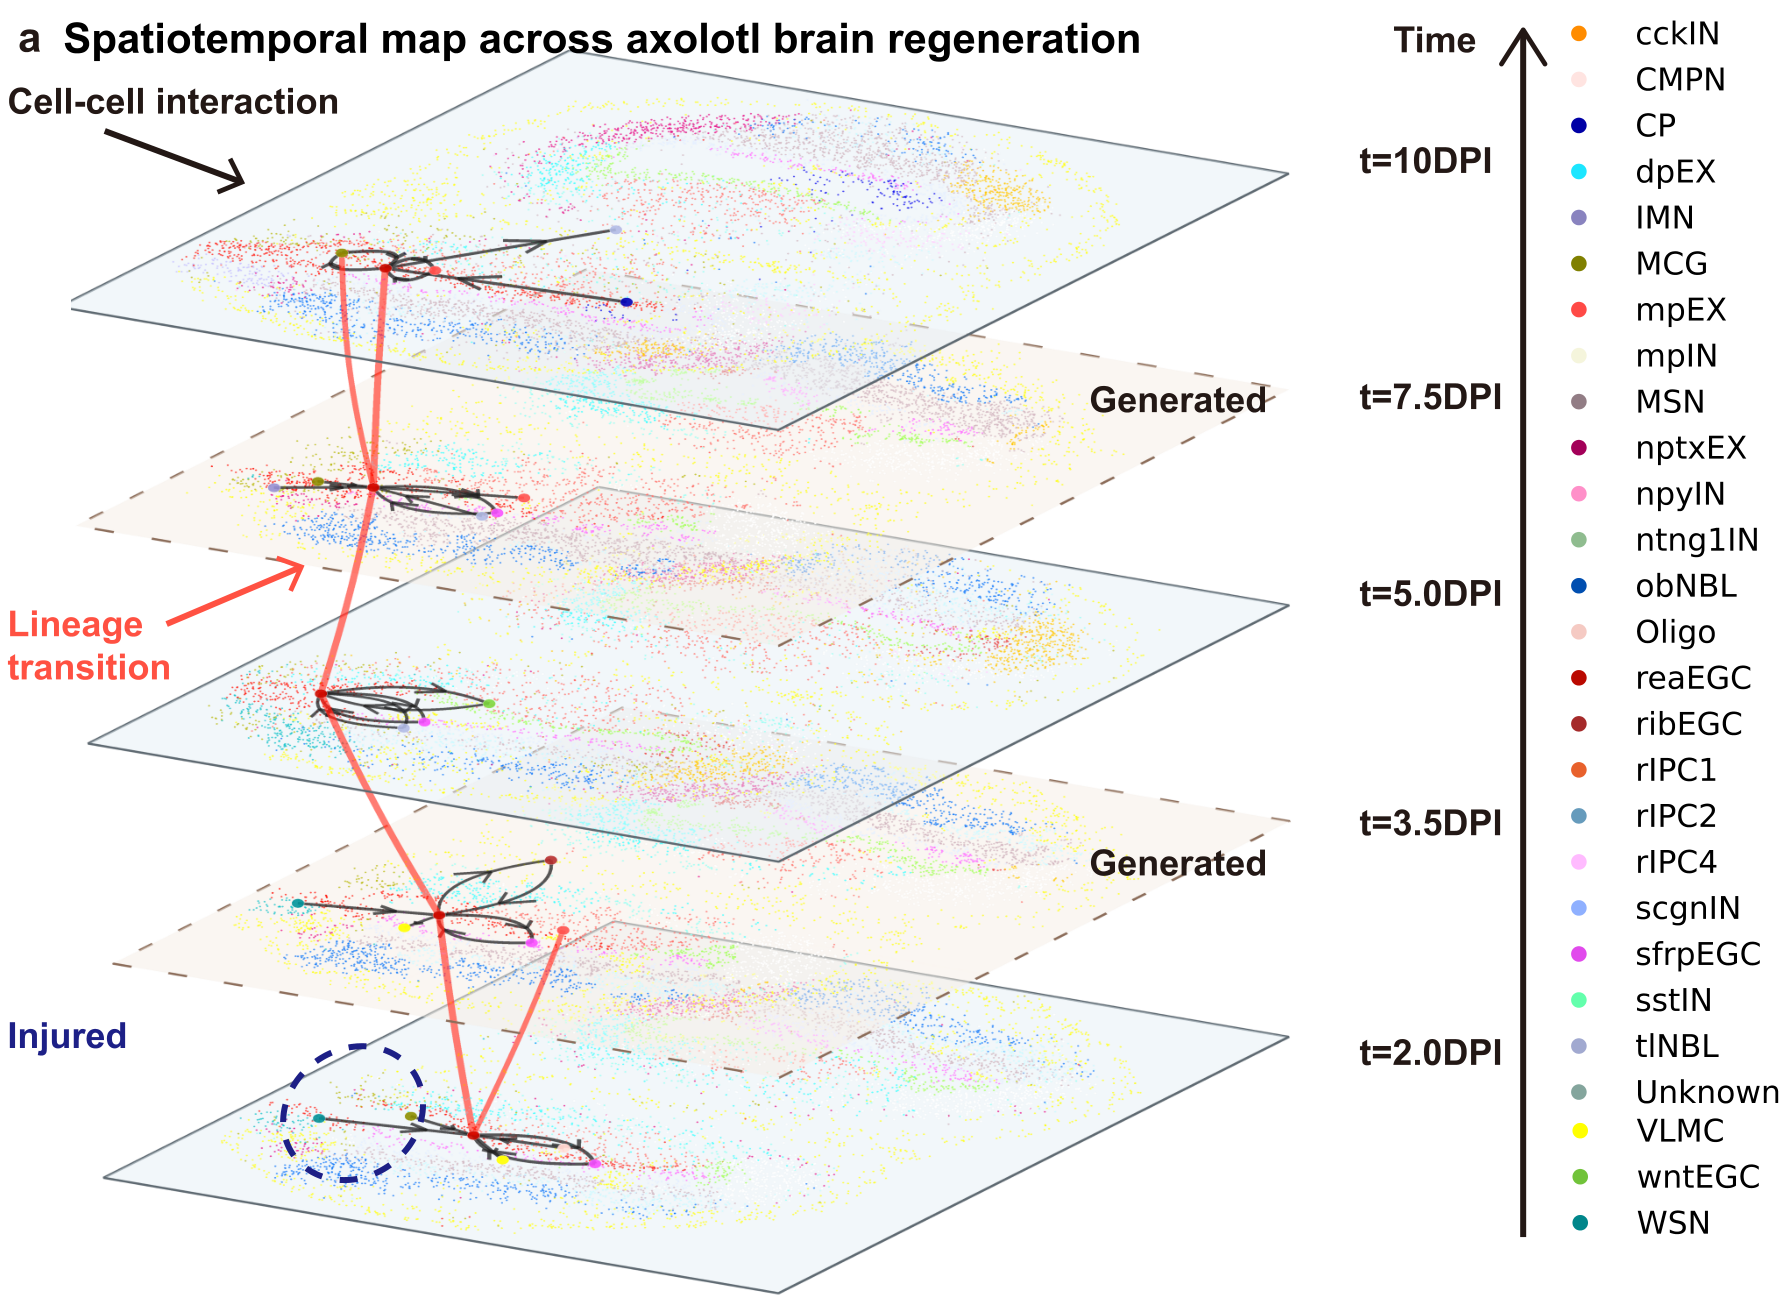

In [3]:
figures = draw_main_figure(data, output, panels="a")
show(figures["a"])

## b. Generated population

Plot the 7,798 generated cells at 3.5 DPI from `display_states/time_0p5.h5ad`. This panel uses the spatially anchored display coordinates. Panel a instead uses the unwarped states from the original simulation.

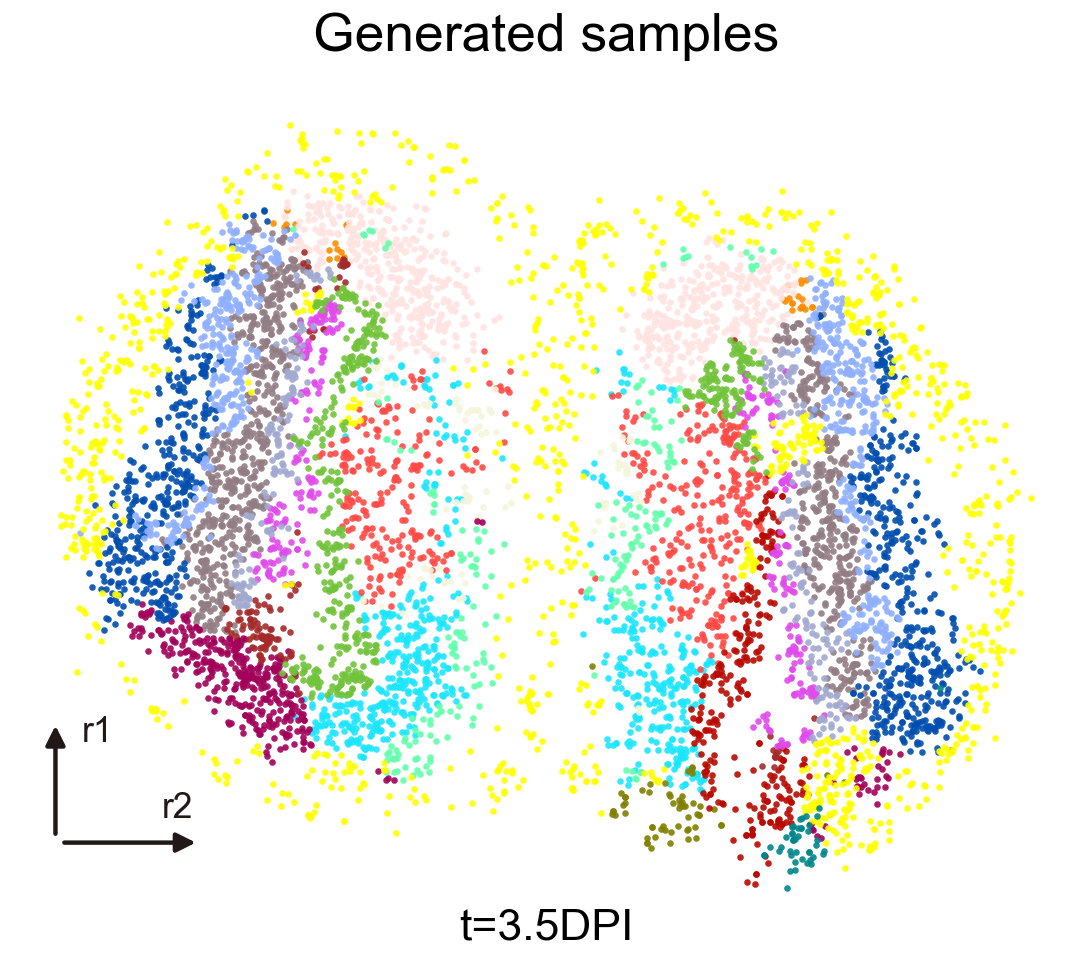

In [4]:
figures = draw_main_figure(data, output, panels="b")
show(figures["b"])

## c. Spatial velocity

The left plot uses the full spatial velocity at 5 DPI. The right plot compares the full and interaction fields after each 52-dimensional field has been projected onto spatial coordinates with a 30-neighbour graph.

For each cell, divide the dot product of these two projected vectors by their lengths to calculate cosine similarity. Draw the enlarged region using that value. The code below performs this calculation before plotting.

In [5]:
with np.load(SOURCE / "figure5c_embedded_velocity.npz", allow_pickle=False) as state:
    full = state["full_embedded_velocity"]
    interaction = state["interaction_embedded_velocity"]
denominator = np.linalg.norm(full, axis=1) * np.linalg.norm(interaction, axis=1)
cosine = np.divide((full * interaction).sum(axis=1), denominator,
                   out=np.zeros(len(full)), where=denominator > 0)
display(pd.Series(cosine, name="cosine similarity").describe())

count    8106.000000
mean       -0.125978
std         0.766982
min        -1.000000
25%        -0.886404
50%        -0.333839
75%         0.724885
max         1.000000
Name: cosine similarity, dtype: float64

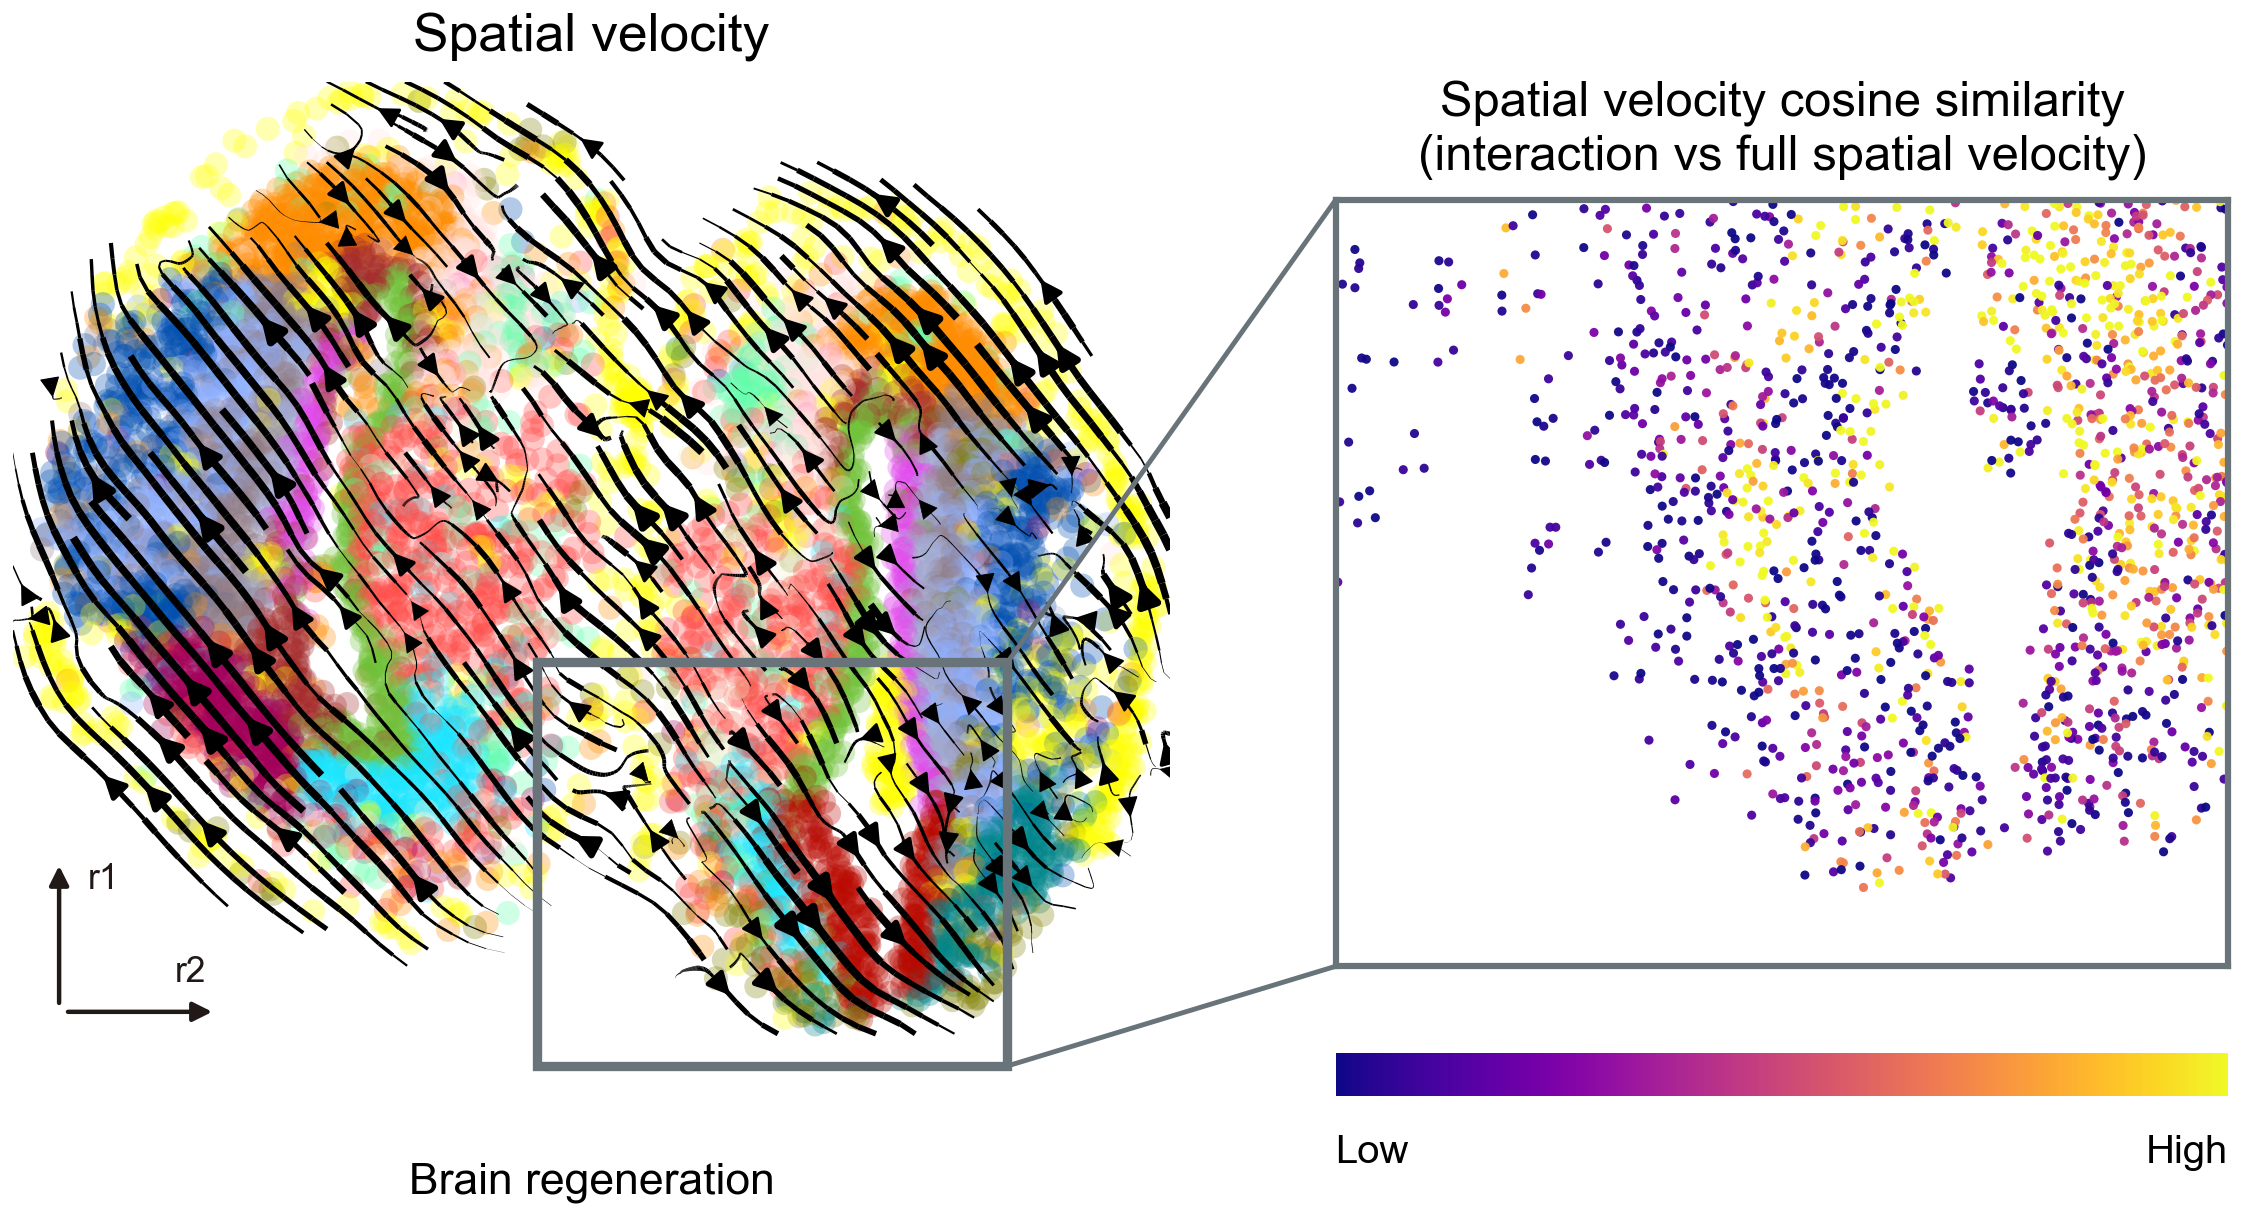

In [6]:
figures = draw_main_figure(data, output, panels="c")
show(figures["c"])

## d. Intrinsic-context gene velocity

This panel uses **intrinsic drift**, not full velocity. Evaluate `model.predict_velocity` on all 46,199 observed cells and take the last 50 (gene-state) dimensions. Fit a two-component PCA to the gene states, construct a 30-neighbour graph in the 50-dimensional space and project the drift into PCA coordinates with scVelo.

The supplied numerical file stores the resulting coordinates and intrinsic vectors. The plotting function interpolates those vectors onto the scVelo streamline grid and uses the original cell-type label positions. The [model calculation](arista_model_fields.md#intrinsic-context-gene-velocity) regenerates this file from the checkpoint.

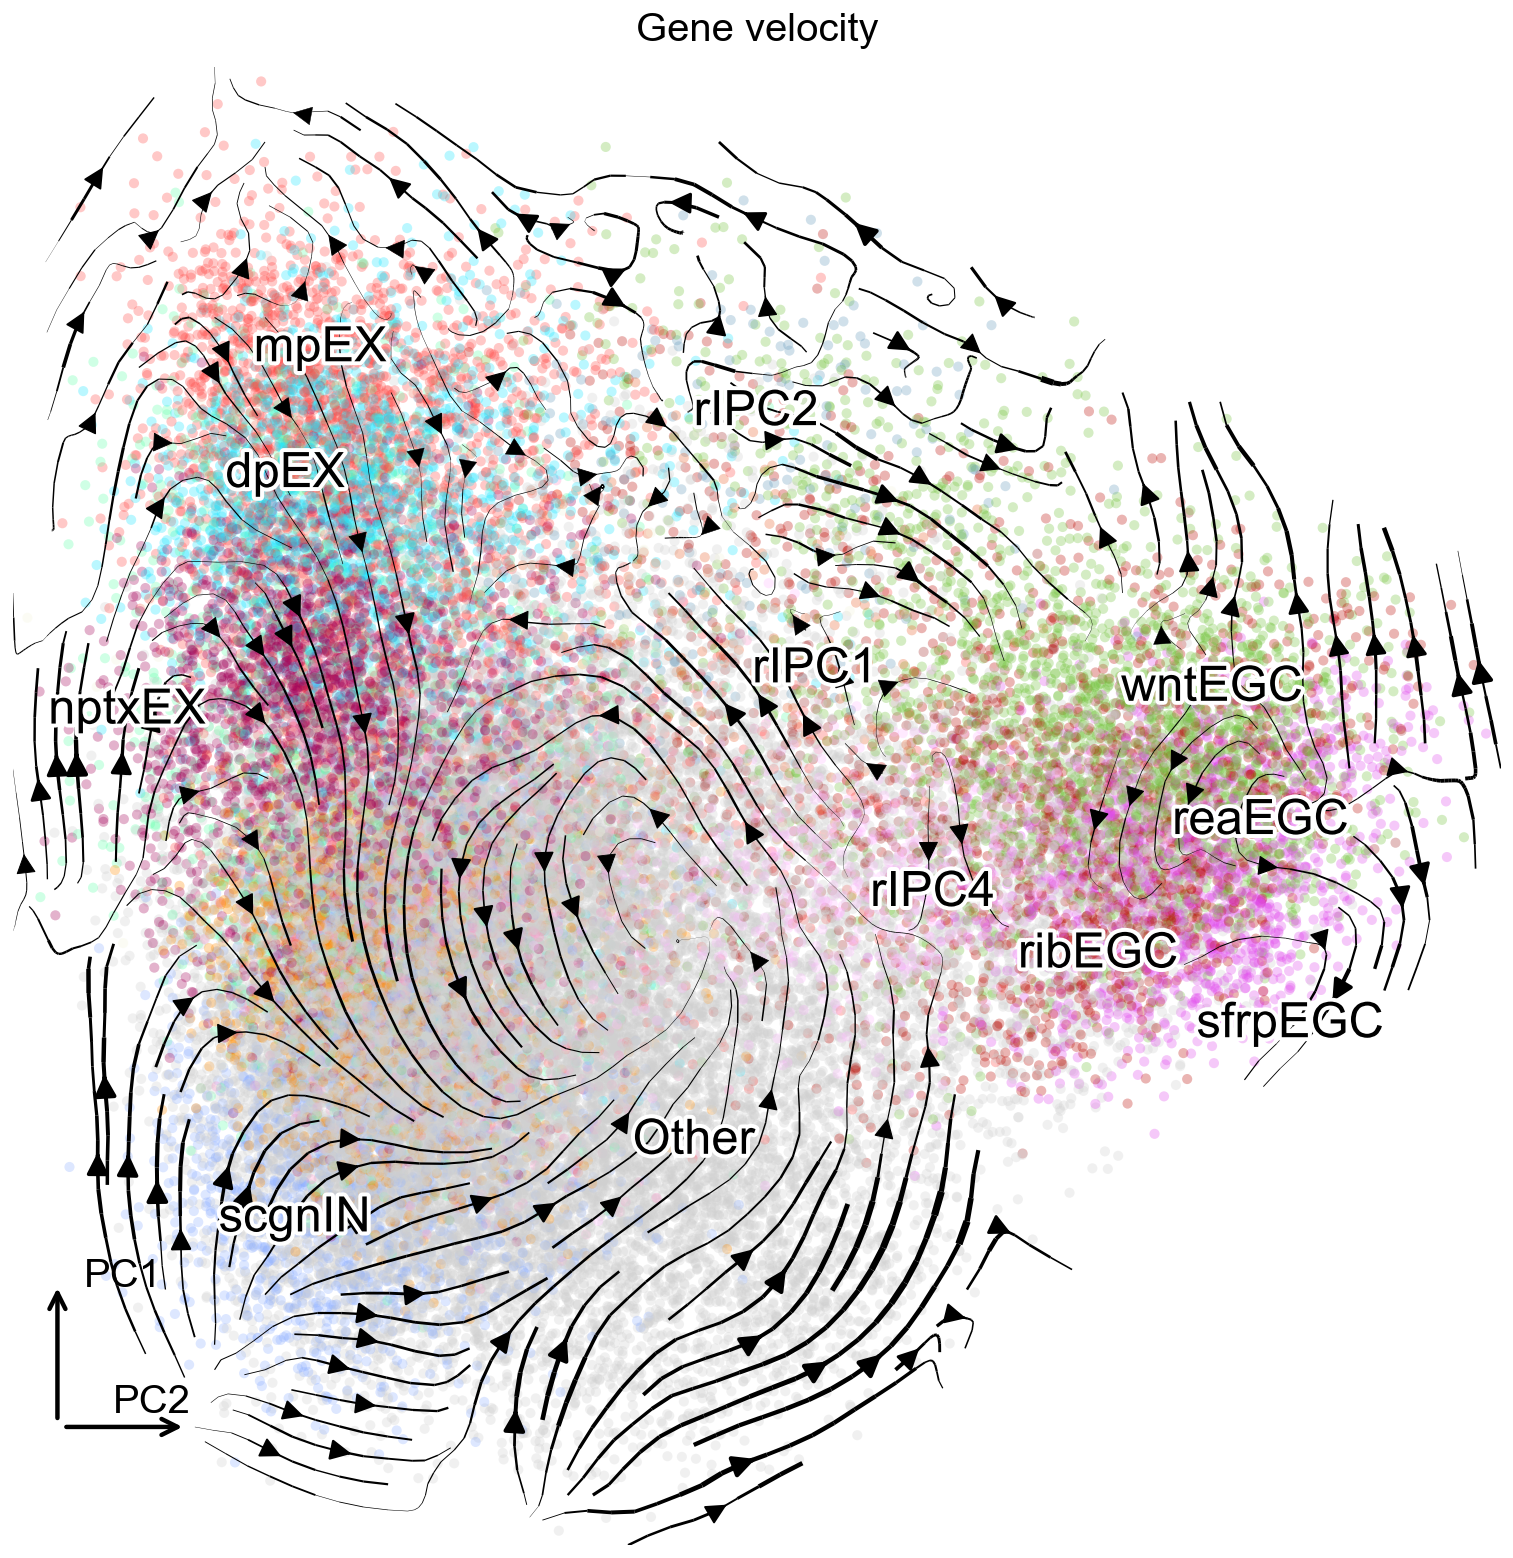

In [7]:
figures = draw_main_figure(data, output, panels="d")
show(figures["d"])

## e. Growth and interaction

Evaluate `model.predict_growth` and the Euclidean norm of the 52-dimensional interaction vector at each of the nine population states. Group the per-cell values by time and cell type, then calculate their arithmetic means. Each circle represents one group and its size encodes the number of cells.

The paper calculation contains 82,306 cells and 177 groups. The nine original input populations are available separately from the display populations. The [model calculation](arista_model_fields.md#growth-and-interaction) shows how to evaluate them.

In [8]:
values = pd.read_csv(SOURCE / "figure5e_growth_interaction_by_cell.csv")
means = values.groupby(["time", "celltype"], as_index=False).agg(
    growth_mean=("growth", "mean"), interaction_mean=("interaction", "mean"),
    cells=("growth", "size"),
)
display(means.head())
print(f"{len(values):,} cells, {len(means)} time-by-cell-type groups")

,time,celltype,growth_mean,interaction_mean,cells
0,0.0,CMPN,0.089906,0.245590,669
1,0.0,MCG,0.048441,0.249597,121
2,0.0,MSN,-0.010620,0.231915,797
3,0.0,Oligo,0.051793,0.431868,92
4,0.0,VLMC,0.035748,0.397752,1300


82,306 cells, 177 time-by-cell-type groups


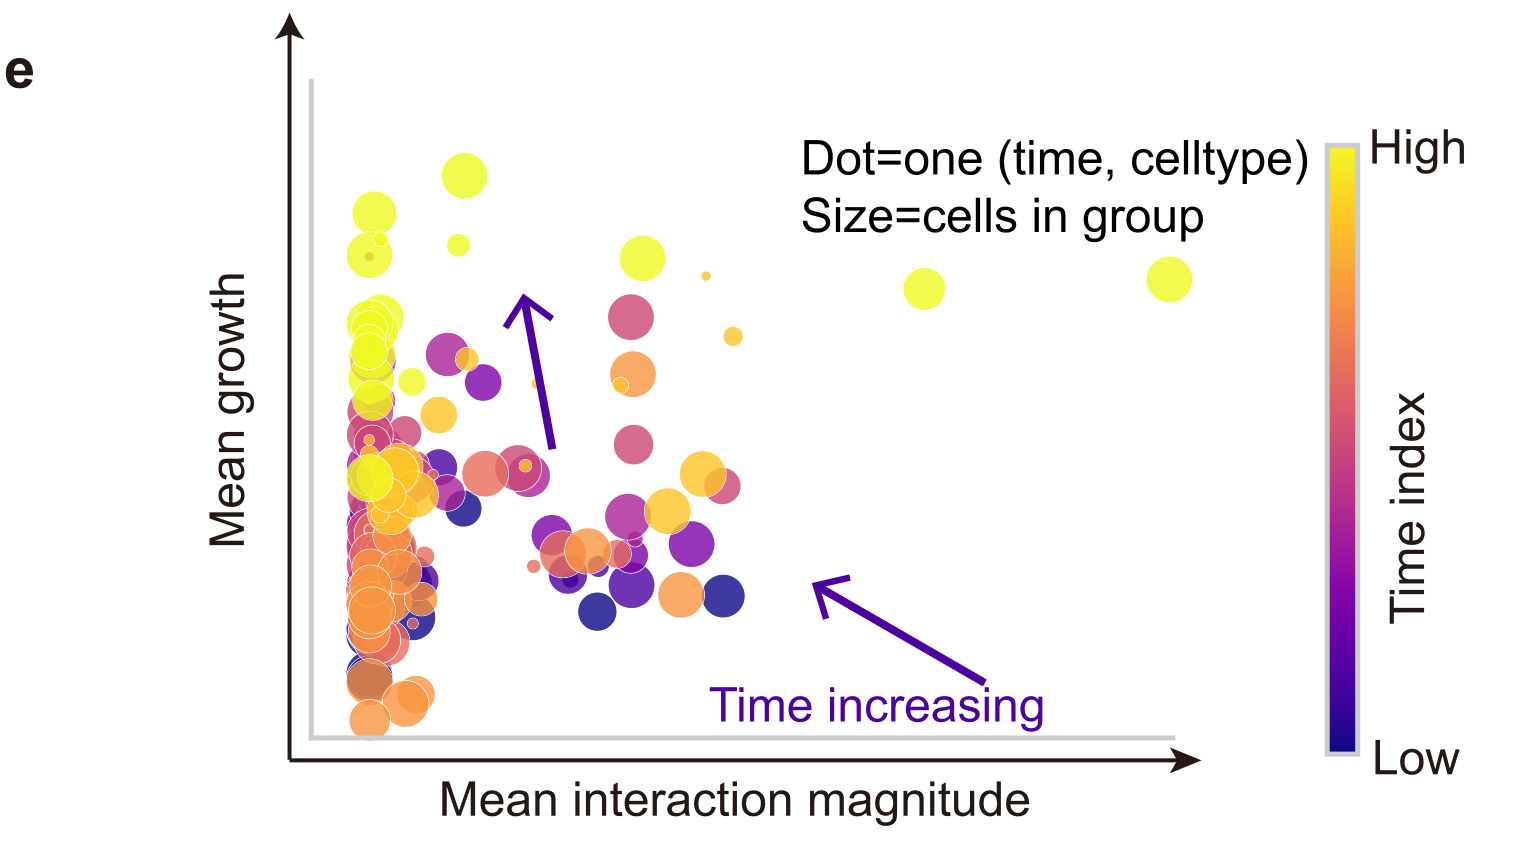

In [9]:
figures = draw_main_figure(data, output, panels="e")
show(figures["e"])